In [1]:
import pandas as pd

df = pd.read_csv("heart.csv")
print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [2]:
from sklearn.model_selection import train_test_split
X=df.drop("target", axis=1)
y=df['target']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [3]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


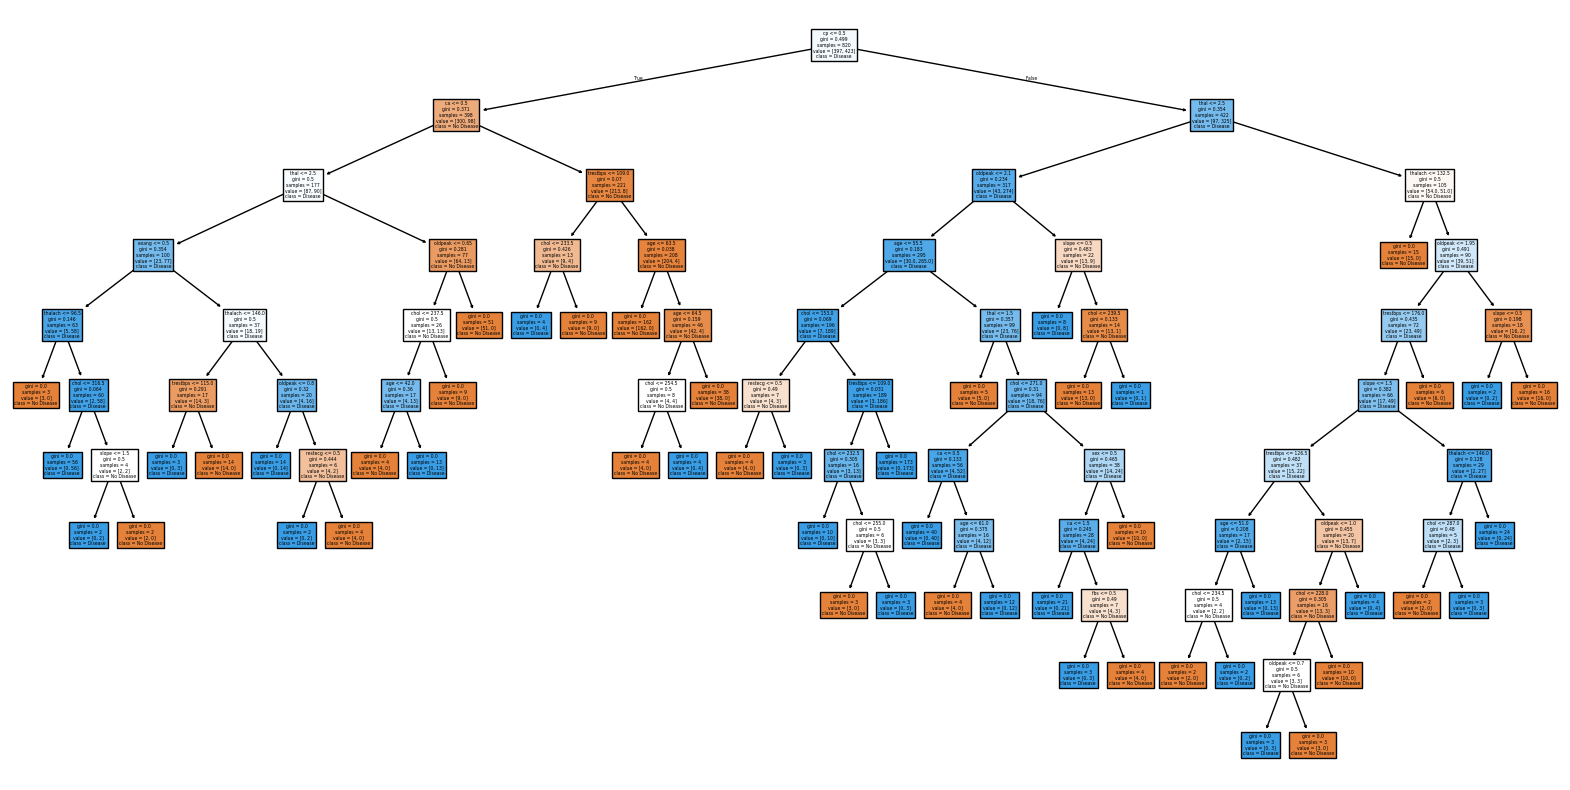

In [4]:
#Visualize tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plot_tree(dt,feature_names=X.columns,
    class_names=["No Disease","Disease"],
    filled=True)
plt.show();

In [5]:
#2.Analyze Overfitting and Control Tree Depth
from sklearn.metrics import accuracy_score
train_pred = dt.predict(X_train)
test_pred = dt.predict(X_test)

print("Train Accuracy:",
      accuracy_score(y_train, train_pred))

print("Test Accuracy:",
      accuracy_score(y_test, test_pred))

Train Accuracy: 1.0
Test Accuracy: 0.9853658536585366


In [6]:
dt_depth = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

dt_depth.fit(X_train, y_train)
print("Train Accuracy:",
      dt_depth.score(X_train,y_train))

print("Test Accuracy:",
      dt_depth.score(X_test,y_test))

Train Accuracy: 0.8512195121951219
Test Accuracy: 0.7804878048780488


In [7]:
#random forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train,y_train)
rf_pred = rf.predict(X_test)

print(
    "Random Forest Accuracy:",
    accuracy_score(y_test, rf_pred)
)

Random Forest Accuracy: 0.9853658536585366


     Feature  Importance
2         cp    0.135072
11        ca    0.127327
7    thalach    0.122169
9    oldpeak    0.121905
12      thal    0.110518
0        age    0.077908
4       chol    0.074822
3   trestbps    0.071171
8      exang    0.057594
10     slope    0.045782
1        sex    0.028731
6    restecg    0.018557
5        fbs    0.008444


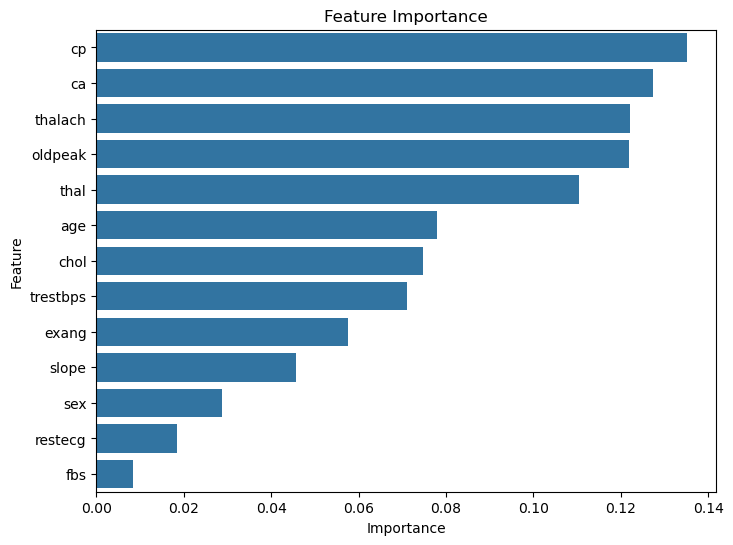

In [9]:
#4.Interpret Feature Importance
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)
import seaborn as sns

plt.figure(figsize=(8,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")
plt.show()

In [10]:
#5. Evaluate Using Cross Validation
from sklearn.model_selection import cross_val_score
scores = cross_val_score(
    rf,
    X,
    y,
    cv=5
)
print(scores)
print(
    "Mean CV Accuracy:",
    scores.mean()
)

[1.         1.         1.         1.         0.98536585]
Mean CV Accuracy: 0.9970731707317073
